# Partial Differential Equations (PDE)
## Crank–Nicolson Method for Reaction-Diffusion Equations

The **explicit** scheme from the previous notebook is simple but *conditionally
stable*: fine grids force tiny time steps.  **Implicit** methods move the spatial
derivative to the future time level, which requires solving a linear system at
each step but allows much larger $\Delta t$.

The **Crank–Nicolson** (CN) method averages the spatial operator at the *current*
and *future* time levels, achieving $O(\Delta t^2)$ accuracy in time while remaining
**unconditionally stable** for the diffusion equation.

| | Explicit (Forward Euler) | Crank–Nicolson |
|--|--|--|
| Time accuracy | $O(\Delta t)$ | $O(\Delta t^2)$ |
| Space accuracy | $O(\Delta x^2)$ | $O(\Delta x^2)$ |
| Stability | Conditional: $\gamma \le \tfrac{1}{2}$ (1-D) | Unconditional |
| Cost per step | $O(N)$ (direct) | $O(N)$ (tridiagonal solve) |

We solve a **1-D reaction-diffusion** equation with homogeneous Neumann
(no-flux) boundary conditions, then extend to a **two-variable coupled system**.

---


## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded   # O(N) banded solver

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

COLORS = ["#94a3b8", "#64748b", "#7c3aed", "#2563eb", "#ea580c"]


## 2 — Derivation of the Crank–Nicolson Scheme

### 2.1 The 1-D Reaction-Diffusion Equation

$$
\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2} + f(u),
\qquad x \in [0,L],\quad t > 0
$$

with **no-flux** (Neumann) boundary conditions:

$$
\left.\frac{\partial u}{\partial x}\right|_{x=0} = 0, \qquad
\left.\frac{\partial u}{\partial x}\right|_{x=L} = 0
$$

### 2.2 The Crank–Nicolson Approximation

The CN scheme averages the *diffusion* term at the current ($k$) and future
($k+1$) time levels, while evaluating the *reaction* term explicitly at $k$
(semi-implicit treatment):

$$
\frac{u_i^{k+1} - u_i^k}{\Delta t}
= \frac{D}{2}\,\frac{u_{i+1}^k - 2u_i^k + u_{i-1}^k}{(\Delta x)^2}
+ \frac{D}{2}\,\frac{u_{i+1}^{k+1} - 2u_i^{k+1} + u_{i-1}^{k+1}}{(\Delta x)^2}
+ f(u_i^k)
$$

### 2.3 Rearranging to a Linear System

Define $r = D\,\Delta t / (2\,(\Delta x)^2)$.  Moving all $k+1$ terms to the
left side and all $k$ terms to the right:

$$
-r\,u_{i-1}^{k+1}
+ (1 + 2r)\,u_i^{k+1}
- r\,u_{i+1}^{k+1}
= r\,u_{i-1}^k
+ (1 - 2r)\,u_i^k
+ r\,u_{i+1}^k
+ \Delta t\,f(u_i^k)
$$

### 2.4 Neumann Boundary Conditions

At the left boundary ($i = 0$), the no-flux condition
$\partial u/\partial x = 0$ is approximated by a ghost-point:
$u_{-1} = u_1$.  Substituting eliminates the ghost node and yields the
modified equation for $i = 0$:

$$
(1 + 2r)\,u_0^{k+1} - 2r\,u_1^{k+1}
= (1 - 2r)\,u_0^k + 2r\,u_1^k + \Delta t\,f(u_0^k)
$$

The right boundary ($i = N-1$) is handled symmetrically.

### 2.5 Matrix Form

Stacking the equations for $i = 0, 1, \ldots, N-1$ gives a tridiagonal system:

$$
\mathbf{A}\,\mathbf{u}^{k+1} = \mathbf{B}\,\mathbf{u}^k + \Delta t\,\mathbf{f}(\mathbf{u}^k)
$$

$$
\mathbf{A} = \begin{pmatrix}
1+2r & -2r \\
-r & 1+2r & -r \\
& \ddots & \ddots & \ddots \\
& & -r & 1+2r & -r \\
& & & -2r & 1+2r
\end{pmatrix}, \quad
\mathbf{B} = \begin{pmatrix}
1-2r & 2r \\
r & 1-2r & r \\
& \ddots & \ddots & \ddots \\
& & r & 1-2r & r \\
& & & 2r & 1-2r
\end{pmatrix}
$$

The **corner entries** ($-2r$ and $+2r$) differ from the interior entries
($-r$ and $+r$) because the Neumann ghost-point doubles the off-diagonal
contribution at the boundary nodes.


## 3 — Scalar Problem: Fisher–KPP Travelling Wave

We solve the **Fisher–KPP** equation, a canonical reaction-diffusion model for
the spread of an advantageous gene (or a biological invasion front):

$$
\frac{\partial u}{\partial t}
= D\,\frac{\partial^2 u}{\partial x^2} + r\,u\,(1 - u),
\qquad u \in [0,1]
$$

The logistic reaction $f(u) = r\,u(1-u)$ promotes growth near $u=0$ and
saturates at $u=1$.  Starting from a localised pulse, the solution develops a
**travelling wave** that propagates at the minimum wave speed
$c^* = 2\sqrt{D\,r}$ and connects the unstable state $u=0$ to the stable
state $u=1$.


In [2]:
# ---- Parameters -------------------------------------------------------
D_kpp = 0.1          # diffusion coefficient
r_kpp = 2.0          # growth rate
L_kpp = 50.0         # domain length
N_kpp = 500          # grid points  — fine grid where CN advantage is clear
t_end = 20.0         # total time

dx = L_kpp / (N_kpp - 1)
x  = np.linspace(0, L_kpp, N_kpp)

# Analytical minimum wave speed and key time scales
c_star      = 2 * np.sqrt(D_kpp * r_kpp)
dt_expl_kpp = dx**2 / (2 * D_kpp)    # explicit diffusion stability limit
dt_react    = 1.0 / r_kpp             # reaction time scale (must be resolved)
dt_kpp      = 0.25                    # CN time step: >> dt_expl but << dt_react

print(f"Grid:     N = {N_kpp},  dx = {dx:.5f}")
print(f"Explicit diffusion limit:  dt <= {dt_expl_kpp:.5f}")
print(f"Reaction time scale 1/r  = {dt_react:.3f}")
print(f"CN uses dt = {dt_kpp:.3f}  ({dt_kpp/dt_expl_kpp:.1f}x the explicit limit)")
print(f"Minimum wave speed c*    = {c_star:.4f}")


def build_CN_matrices(N, r_coeff):
    "Build A (implicit) and B (explicit) tridiagonal CN matrices in banded form."
    # A: diagonal = 1+2*r_coeff, off-diags = -r_coeff, Neumann corners = -2*r_coeff.
    # B: diagonal = 1-2*r_coeff, off-diags = +r_coeff, Neumann corners = +2*r_coeff.
    # Returns (ab_A, ab_B) for scipy.linalg.solve_banded: rows = [upper, main, lower].
    # --- Matrix A (left-hand side) ---
    diag_A  = np.full(N, 1 + 2 * r_coeff)
    upper_A = np.full(N - 1, -r_coeff)
    lower_A = np.full(N - 1, -r_coeff)
    # Neumann corners: ghost point folds in, doubling the off-diagonal
    upper_A[0]  = -2 * r_coeff
    lower_A[-1] = -2 * r_coeff

    ab_A = np.zeros((3, N))
    ab_A[0, 1:]  = upper_A
    ab_A[1, :]   = diag_A
    ab_A[2, :-1] = lower_A

    # --- Matrix B (right-hand side, dense-vector multiplication) ---
    diag_B  = np.full(N, 1 - 2 * r_coeff)
    upper_B = np.full(N - 1, r_coeff)
    lower_B = np.full(N - 1, r_coeff)
    upper_B[0]  = 2 * r_coeff
    lower_B[-1] = 2 * r_coeff

    # Pack B as (3, N) for tridiagonal matvec
    ab_B = np.zeros((3, N))
    ab_B[0, 1:]  = upper_B
    ab_B[1, :]   = diag_B
    ab_B[2, :-1] = lower_B

    return ab_A, ab_B


def tridiag_matvec(ab, v):
    "Multiply tridiagonal matrix (banded form) by vector v."
    N   = len(v)
    out = ab[1] * v
    out[:-1] += ab[0, 1:] * v[1:]
    out[1:]  += ab[2, :-1] * v[:-1]
    return out


def solve_fisher_kpp(N, dx_val, L_val, t_val, D, r, dt):
    "Solve Fisher-KPP with CN at a given absolute dt."
    r_coeff = D * dt / (2 * dx_val**2)
    n_steps = int(np.ceil(t_val / dt))
    ab_A, ab_B = build_CN_matrices(N, r_coeff)

    x_loc = np.linspace(0, L_val, N)
    u = np.where(x_loc < 5.0, 1.0, 0.0).astype(float)

    save_every = max(1, n_steps // 8)
    times  = [0.0];  fields = [u.copy()]

    for k in range(n_steps):
        rhs = tridiag_matvec(ab_B, u) + dt * r * u * (1 - u)
        u   = solve_banded((1, 1), ab_A, rhs)
        if (k + 1) % save_every == 0:
            times.append((k + 1) * dt)
            fields.append(u.copy())

    return np.array(times), fields, r_coeff


times_kpp, fields_kpp, r_kpp_coeff = solve_fisher_kpp(
    N_kpp, dx, L_kpp, t_end, D_kpp, r_kpp, dt_kpp)
n_steps_kpp = int(np.ceil(t_end / dt_kpp))
print(f"r_coeff = {r_kpp_coeff:.4f}")
print(f"Steps: {n_steps_kpp}   snapshots: {len(times_kpp)}")


Grid:     N = 500,  dx = 0.10020
Explicit diffusion limit:  dt <= 0.05020
Reaction time scale 1/r  = 0.500
CN uses dt = 0.250  (5.0x the explicit limit)
Minimum wave speed c*    = 0.8944
r_coeff = 1.2450
Steps: 80   snapshots: 9


## 4 — Travelling Wave: Solution and Convergence

The eight panels below show the developing travelling wave.  The left-to-right
propagation speed approaches $c^* = 2\sqrt{Dr}$ as $t \to \infty$.

Because CN is unconditionally stable, we can use $\Delta t = 0.25$ — which is
**5× larger** than the explicit diffusion stability limit of $0.050$.


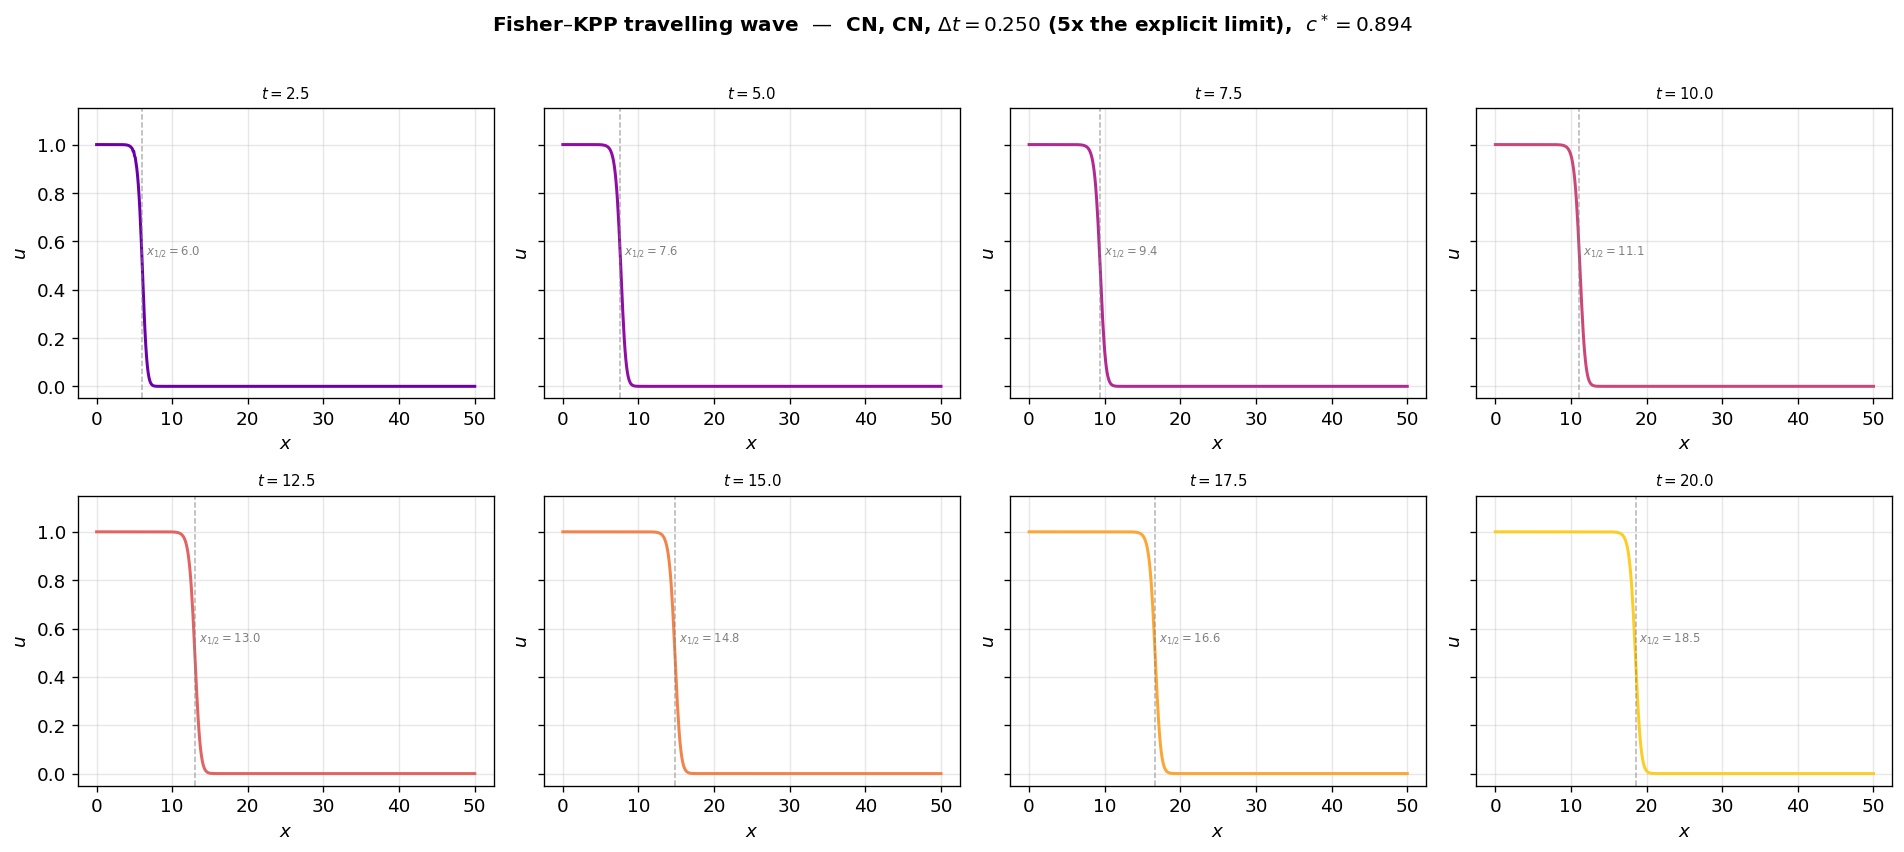

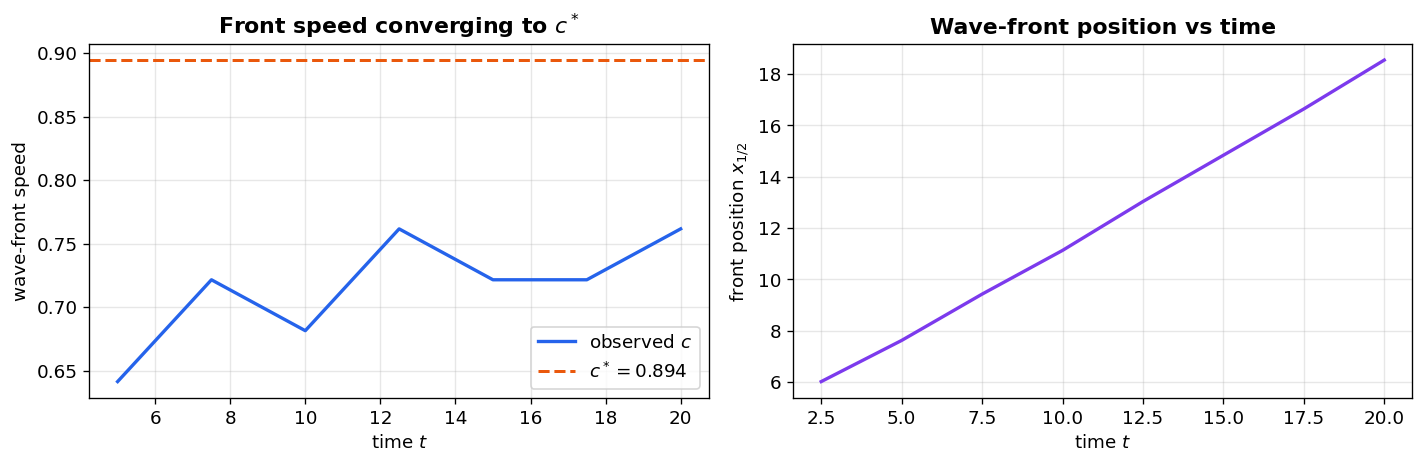

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)

cmap_wave = plt.cm.plasma
snaps = list(zip(times_kpp[1:], fields_kpp[1:]))[:8]

for ax, (t, u_snap) in zip(axes.flat, snaps):
    ax.plot(x, u_snap, color=cmap_wave(0.1 + 0.8 * (t / t_end)), lw=1.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$u$")
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(f"$t = {t:.1f}$", fontsize=9, fontweight="bold")
    # Mark the wave front (u = 0.5 crossing)
    idx = np.argmin(np.abs(u_snap - 0.5))
    ax.axvline(x[idx], color="grey", lw=0.9, ls="--", alpha=0.6)
    ax.text(x[idx] + 0.5, 0.55, f"$x_{{1/2}}={x[idx]:.1f}$",
            fontsize=7, color="grey")

fig.suptitle(
    f"Fisher–KPP travelling wave  —  CN, "
    f"CN, $\\Delta t = {dt_kpp:.3f}$ ({dt_kpp/dt_expl_kpp:.0f}x the explicit limit),  $c^* = {c_star:.3f}$",
    fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

# Track the wave-front position over time
fronts = [x[np.argmin(np.abs(f - 0.5))] for f in fields_kpp[1:]]
speeds = np.diff(fronts) / np.diff(times_kpp[1:])

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

axes2[0].plot(times_kpp[2:], speeds, color=COLORS[3], lw=2, label="observed $c$")
axes2[0].axhline(c_star, color=COLORS[4], ls="--", lw=1.8,
                 label=f"$c^* = {c_star:.3f}$")
axes2[0].set_xlabel("time $t$")
axes2[0].set_ylabel("wave-front speed")
axes2[0].set_title("Front speed converging to $c^*$", fontweight="bold")
axes2[0].legend()

axes2[1].plot(times_kpp[1:], fronts, color=COLORS[2], lw=2)
axes2[1].set_xlabel("time $t$")
axes2[1].set_ylabel("front position $x_{1/2}$")
axes2[1].set_title("Wave-front position vs time", fontweight="bold")

fig2.tight_layout()
plt.show()


## 5 — CN vs Explicit: Stability and Efficiency

We compare Crank–Nicolson (unconditionally stable) to the explicit scheme
(conditionally stable) using the same spatial grid at **four different time-step
sizes**.  The explicit scheme diverges once $\gamma > \tfrac{1}{2}$
($\Delta t > \Delta t_{\text{max}}^{\text{expl}}$); CN remains stable throughout.


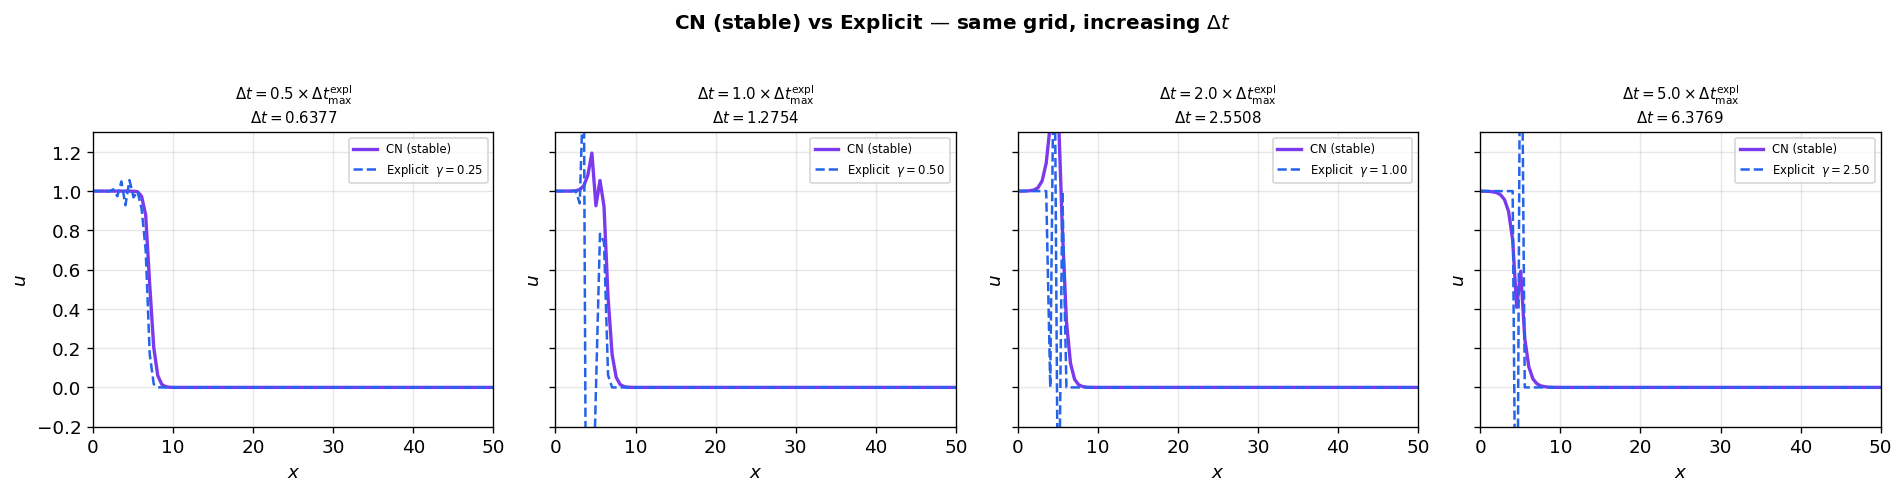

In [4]:
def solve_explicit_kpp(N, dx, t_end, D, r, dt_factor):
    "Explicit (forward Euler) Fisher-KPP solver."
    dt_expl = dx**2 / (2 * D)
    dt      = dt_factor * dt_expl
    gamma   = D * dt / dx**2
    n_steps = int(np.ceil(t_end / dt))

    x_loc = np.linspace(0, L_kpp, N)
    u = np.where(x_loc < 5.0, 1.0, 0.0).astype(float)

    for k in range(n_steps):
        u_new       = u.copy()
        u_new[1:-1] = u[1:-1] + gamma * (u[2:] - 2*u[1:-1] + u[:-2]) + dt*r*u[1:-1]*(1-u[1:-1])
        u_new[0]    = u_new[1];   u_new[-1] = u_new[-2]  # Neumann
        u = u_new
        if np.any(np.abs(u) > 1e6):
            return None, gamma          # diverged
    return u, gamma


N_cmp   = 100
dx_cmp  = L_kpp / (N_cmp - 1)
x_cmp   = np.linspace(0, L_kpp, N_cmp)
t_cmp   = 5.0
dt_expl_cmp = dx_cmp**2 / (2 * D_kpp)

dt_factors = [0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, dtf in zip(axes, dt_factors):
    dt_use = dtf * dt_expl_cmp

    # CN solution
    dt_cmp = dtf * (dx_cmp**2 / (2 * D_kpp))
    _, f_cn, _ = solve_fisher_kpp(N_cmp, dx_cmp, L_kpp, t_cmp, D_kpp, r_kpp, dt_cmp)
    u_cn = f_cn[-1]

    # Explicit solution
    u_ex, gamma_ex = solve_explicit_kpp(N_cmp, dx_cmp, t_cmp, D_kpp, r_kpp, dt_factor=dtf)

    stable_ex = u_ex is not None
    label_ex = f"Explicit  $\\gamma={gamma_ex:.2f}$" + ("" if stable_ex else "  ✗ DIVERGED")
    col_ex   = COLORS[3] if stable_ex else COLORS[4]

    ax.plot(x_cmp, u_cn, color=COLORS[2], lw=2.0, label="CN (stable)")
    if stable_ex:
        ax.plot(x_cmp, u_ex, color=col_ex, lw=1.5, ls="--", label=label_ex)
    else:
        ax.text(0.5, 0.5, "EXPLICIT\nDIVERGED", transform=ax.transAxes,
                ha="center", va="center", fontsize=11, color=COLORS[4],
                fontweight="bold", alpha=0.7)
        ax.plot([], [], color=col_ex, ls="--", lw=1.5, label=label_ex)

    ax.set_xlim(0, L_kpp)
    ax.set_ylim(-0.2, 1.3)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$u$")
    ax.set_title(
        f"$\\Delta t = {dtf:.1f}\\times\\Delta t_{{\\max}}^{{\\text{{expl}}}}$\n"
        f"$\\Delta t = {dt_use:.4f}$",
        fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("CN (stable) vs Explicit — same grid, increasing $\\Delta t$",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 6 — Time-Step Convergence: $O(\Delta t^2)$ Verification

CN's second-order accuracy in time is verified using a **pure diffusion**
problem with a known analytical solution.

We solve $\partial u/\partial t = D\,\partial^2 u/\partial x^2$ on $[0, L]$
with Neumann BCs and the initial condition

$$
u(x,0) = \cos\!\left(\frac{\pi x}{L}\right)
         + \tfrac{1}{2}\cos\!\left(\frac{2\pi x}{L}\right)
$$

The exact solution is

$$
u(x,t)
= e^{-D(\pi/L)^2 t}\cos\!\left(\frac{\pi x}{L}\right)
+ \tfrac{1}{2}\,e^{-D(2\pi/L)^2 t}\cos\!\left(\frac{2\pi x}{L}\right)
$$

Because the exact solution is available, the error can be computed directly
(no reference solver needed) and only the temporal discretisation error
is measured — the spatial error is negligible for the fine grid used.

> **Note:** The Fisher–KPP solver in sections 3–5 treats the *reaction* term
> explicitly, making the overall scheme $O(\Delta t)$ in time.  For pure
> diffusion — or when the reaction is also linearised and treated implicitly —
> CN recovers its full $O(\Delta t^2)$ accuracy.


Pure-diffusion test:  D=1.0, L=1.0, N=100, t=0.5
1st eigenvalue D*(pi/L)^2 = 9.8696  (controls decay rate)
dx = 0.01010,  spatial error floor ~ O(dx^2) ~ 1.02e-04

      dt   steps     RMS error
--------------------------------
  0.0050     100   3.0015e-06
  0.0100      50   1.8348e-05
  0.0200      25   7.9609e-05
  0.0500      10   5.0265e-04
  0.1000       5   2.3389e-03


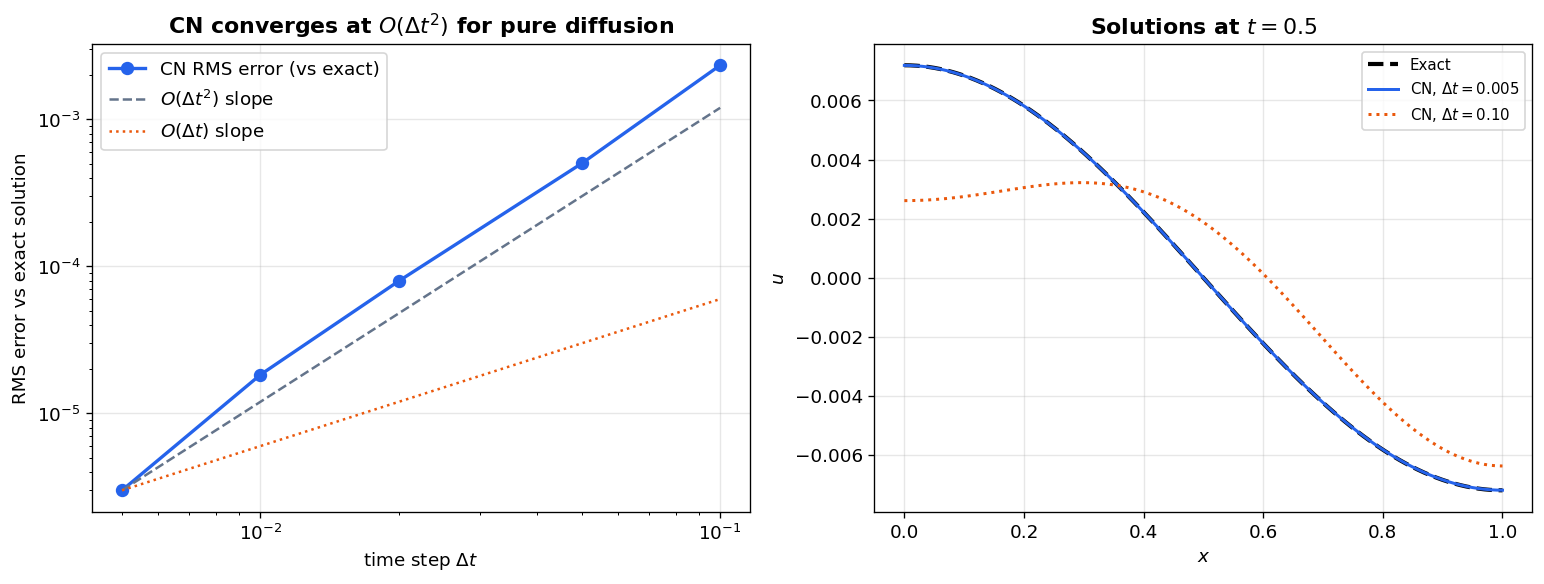

In [5]:
# Pure-diffusion analytical test — use D=1, L=1 so CN temporal error dominates
D_acc  = 1.0       # fast diffusion: eigenvalue D*(pi/L)^2 = pi^2 ~ 9.87
L_acc  = 1.0
N_acc  = 100       # fine spatial grid — spatial error ~ 1e-7 (negligible)
t_acc  = 0.50      # long enough that mode 2 has decayed; all dt give ≥5 steps

dx_acc = L_acc / (N_acc - 1)
x_acc  = np.linspace(0, L_acc, N_acc)

def u_exact(x, t, D, L):
    "Exact solution: two cosine modes decaying in time."
    lam1 = D * (np.pi / L)**2
    lam2 = D * (2 * np.pi / L)**2
    return np.exp(-lam1 * t) * np.cos(np.pi * x / L) + \
           0.5 * np.exp(-lam2 * t) * np.cos(2 * np.pi * x / L)

def solve_pure_diffusion_CN(N, dx, L, D, t_end, dt):
    "CN solver for pure diffusion (no reaction) on [0,L] with Neumann BCs."
    r_coeff = D * dt / (2 * dx**2)
    ab_A, ab_B = build_CN_matrices(N, r_coeff)
    x_l = np.linspace(0, L, N)
    u = u_exact(x_l, 0.0, D, L)
    n_steps = int(np.ceil(t_end / dt))
    for k in range(n_steps):
        u = solve_banded((1, 1), ab_A, tridiag_matvec(ab_B, u))
    return u


dt_vals_acc = [0.005, 0.01, 0.02, 0.05, 0.10]
errors_acc  = []
u_true      = u_exact(x_acc, t_acc, D_acc, L_acc)

print(f"Pure-diffusion test:  D={D_acc}, L={L_acc}, N={N_acc}, t={t_acc}")
print(f"1st eigenvalue D*(pi/L)^2 = {D_acc*(np.pi/L_acc)**2:.4f}  (controls decay rate)")
print(f"dx = {dx_acc:.5f},  spatial error floor ~ O(dx^2) ~ {dx_acc**2:.2e}")
print()
print(f"{'dt':>8}  {'steps':>6}  {'RMS error':>12}")
print("-" * 32)
for dt in dt_vals_acc:
    u_num = solve_pure_diffusion_CN(N_acc, dx_acc, L_acc, D_acc, t_acc, dt)
    rms   = float(np.sqrt(np.mean((u_num - u_true)**2)))
    errors_acc.append(rms)
    print(f"  {dt:.4f}   {int(np.ceil(t_acc/dt)):>5d}   {rms:.4e}")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: log-log convergence
h0, hN = dt_vals_acc[0], dt_vals_acc[-1]
axes[0].loglog(dt_vals_acc, errors_acc, "o-", color=COLORS[3], lw=2,
               markersize=7, label="CN RMS error (vs exact)")
axes[0].loglog([h0, hN], [errors_acc[0] * (h/h0)**2 for h in [h0, hN]],
               "--", color=COLORS[1], lw=1.5, label=r"$O(\Delta t^2)$ slope")
axes[0].loglog([h0, hN], [errors_acc[0] * (h/h0)**1 for h in [h0, hN]],
               ":",  color=COLORS[4], lw=1.5, label=r"$O(\Delta t)$ slope")
axes[0].set_xlabel(r"time step $\Delta t$")
axes[0].set_ylabel("RMS error vs exact solution")
axes[0].set_title(r"CN converges at $O(\Delta t^2)$ for pure diffusion",
                  fontweight="bold")
axes[0].legend()

# Right: solution at coarse and fine dt
u_coarse = solve_pure_diffusion_CN(N_acc, dx_acc, L_acc, D_acc, t_acc, dt=0.10)
u_fine   = solve_pure_diffusion_CN(N_acc, dx_acc, L_acc, D_acc, t_acc, dt=0.005)
axes[1].plot(x_acc, u_true,   color="k",       lw=2.5, ls="--", label="Exact")
axes[1].plot(x_acc, u_fine,   color=COLORS[3], lw=1.8,          label=r"CN, $\Delta t=0.005$")
axes[1].plot(x_acc, u_coarse, color=COLORS[4], lw=1.8, ls=":",  label=r"CN, $\Delta t=0.10$")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u$")
axes[1].set_title(f"Solutions at $t = {t_acc}$", fontweight="bold")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()


## 7 — Two-Variable Reaction-Diffusion System

### 7.1 The Equations

Many pattern-forming processes in biology and chemistry are described by
coupled reaction-diffusion systems of the form

$$
\frac{\partial u}{\partial t}
= D_u \frac{\partial^2 u}{\partial x^2} + f(u,v), \qquad
\frac{\partial v}{\partial t}
= D_v \frac{\partial^2 v}{\partial x^2} + g(u,v)
$$

We use the **Schnakenberg kinetics**, a minimal activator–inhibitor model
that produces Turing patterns:

$$
f(u,v) = a - u + u^2 v, \qquad
g(u,v) = b - u^2 v
$$

At steady state the homogeneous equilibrium is
$u_0 = a + b$, $v_0 = b/(a+b)^2$.
The Turing instability occurs when the **inhibitor diffuses faster** than the
activator ($D_v > D_u$), generating spatially periodic concentration patterns.

### 7.2 The Coupled CN Scheme

Each variable gets its own tridiagonal system.  The reaction terms are
treated explicitly.  At every time step we solve *two independent
tridiagonal systems* (one for $u$, one for $v$), with the coupling
entering only through the right-hand-side reaction vectors:

$$
\mathbf{A}_u\,\mathbf{u}^{k+1}
= \mathbf{B}_u\,\mathbf{u}^k + \Delta t\,\mathbf{f}(\mathbf{u}^k,\mathbf{v}^k),
\qquad
\mathbf{A}_v\,\mathbf{v}^{k+1}
= \mathbf{B}_v\,\mathbf{v}^k + \Delta t\,\mathbf{g}(\mathbf{u}^k,\mathbf{v}^k)
$$

The matrices $\mathbf{A}_u$ and $\mathbf{B}_u$ depend only on $D_u$;
$\mathbf{A}_v$ and $\mathbf{B}_v$ depend only on $D_v$.  Because both
matrices are pre-computed and fixed, the dominant cost per step is two
$O(N)$ tridiagonal back-substitutions.


In [6]:
# ---- Schnakenberg parameters (Turing instability regime) ---------------
# Turing wavelength for these kinetics: lambda_T ~ 11.4 units
# Use L=50 so ~4 full wavelengths fit in the domain
a_sc  = 0.1
b_sc  = 0.9
Du    = 1.0          # activator diffusivity
Dv    = 40.0         # inhibitor diffusivity (Turing: Dv >> Du)
L_sc  = 50.0         # domain — holds several Turing wavelengths
N_sc  = 500          # 500 points → dx = 0.1002
t_sc  = 200.0        # allow patterns to fully saturate

dx_sc = L_sc / (N_sc - 1)
x_sc  = np.linspace(0, L_sc, N_sc)

# Homogeneous steady state
u0_ss = a_sc + b_sc
v0_ss = b_sc / (a_sc + b_sc)**2
print(f"Schnakenberg steady state:  u0 = {u0_ss:.4f},  v0 = {v0_ss:.4f}")

# Turing instability window from linear analysis
disc    = 31.0**2 - 4*40.0*1.0       # (Dv*fu - gv)^2 - 4*Du*Dv*detJ
k2_low  = (31 - np.sqrt(disc)) / 80
k2_high = (31 + np.sqrt(disc)) / 80
lambda_T = 2*np.pi / np.sqrt((k2_low+k2_high)/2)
print(f"Turing wavelength ~ {lambda_T:.1f}  →  ~{L_sc/lambda_T:.1f} peaks in domain")

dt_expl_sc = dx_sc**2 / (2 * Du)
dt_sc      = 0.1      # CN dt — reaction time scale ~ 1/b ~ 1.1
print(f"Explicit stability limit dt_max = {dt_expl_sc:.2e}")
print(f"CN uses dt = {dt_sc:.3f}  (~{dt_sc/dt_expl_sc:.0f}x larger than explicit limit)")


def solve_schnakenberg(N, dx, t_end, Du, Dv, a, b, dt):
    "Two-variable CN solver for Schnakenberg kinetics."
    ru = Du * dt / (2 * dx**2)
    rv = Dv * dt / (2 * dx**2)

    ab_Au, ab_Bu = build_CN_matrices(N, ru)
    ab_Av, ab_Bv = build_CN_matrices(N, rv)

    # Initial condition: small random perturbation around steady state
    rng  = np.random.default_rng(42)
    u0ss = a + b
    v0ss = b / (a + b)**2
    u = u0ss + 0.01 * rng.standard_normal(N)
    v = v0ss + 0.01 * rng.standard_normal(N)

    n_steps    = int(np.ceil(t_end / dt))
    save_every = max(1, n_steps // 8)
    times  = [0.0]
    u_snaps = [u.copy()]
    v_snaps = [v.copy()]

    for k in range(n_steps):
        # Reaction terms (explicit)
        fu = a - u + u**2 * v
        fv = b - u**2 * v

        # Solve for u^{k+1}
        rhs_u = tridiag_matvec(ab_Bu, u) + dt * fu
        u_new = solve_banded((1, 1), ab_Au, rhs_u)

        # Solve for v^{k+1}
        rhs_v = tridiag_matvec(ab_Bv, v) + dt * fv
        v_new = solve_banded((1, 1), ab_Av, rhs_v)

        u, v = u_new, v_new

        if (k + 1) % save_every == 0:
            times.append((k + 1) * dt)
            u_snaps.append(u.copy())
            v_snaps.append(v.copy())

    return np.array(times), u_snaps, v_snaps


times_sc, u_snaps, v_snaps = solve_schnakenberg(
    N_sc, dx_sc, t_sc, Du, Dv, a_sc, b_sc, dt_sc)
print(f"Steps: {int(np.ceil(t_sc/dt_sc))}  snapshots: {len(times_sc)}")


Schnakenberg steady state:  u0 = 1.0000,  v0 = 0.9000
Turing wavelength ~ 10.1  →  ~5.0 peaks in domain
Explicit stability limit dt_max = 5.02e-03
CN uses dt = 0.100  (~20x larger than explicit limit)
Steps: 2000  snapshots: 9


## 8 — Turing Pattern Formation

Starting from a tiny random perturbation around the homogeneous steady state,
the Turing instability amplifies certain spatial wavenumbers.  The short-range
activation ($u$) combined with long-range inhibition ($v$) produces a
self-organising spatial pattern with a **characteristic wavelength** that depends
only on the diffusion coefficients and the reaction parameters — not on the
initial condition.


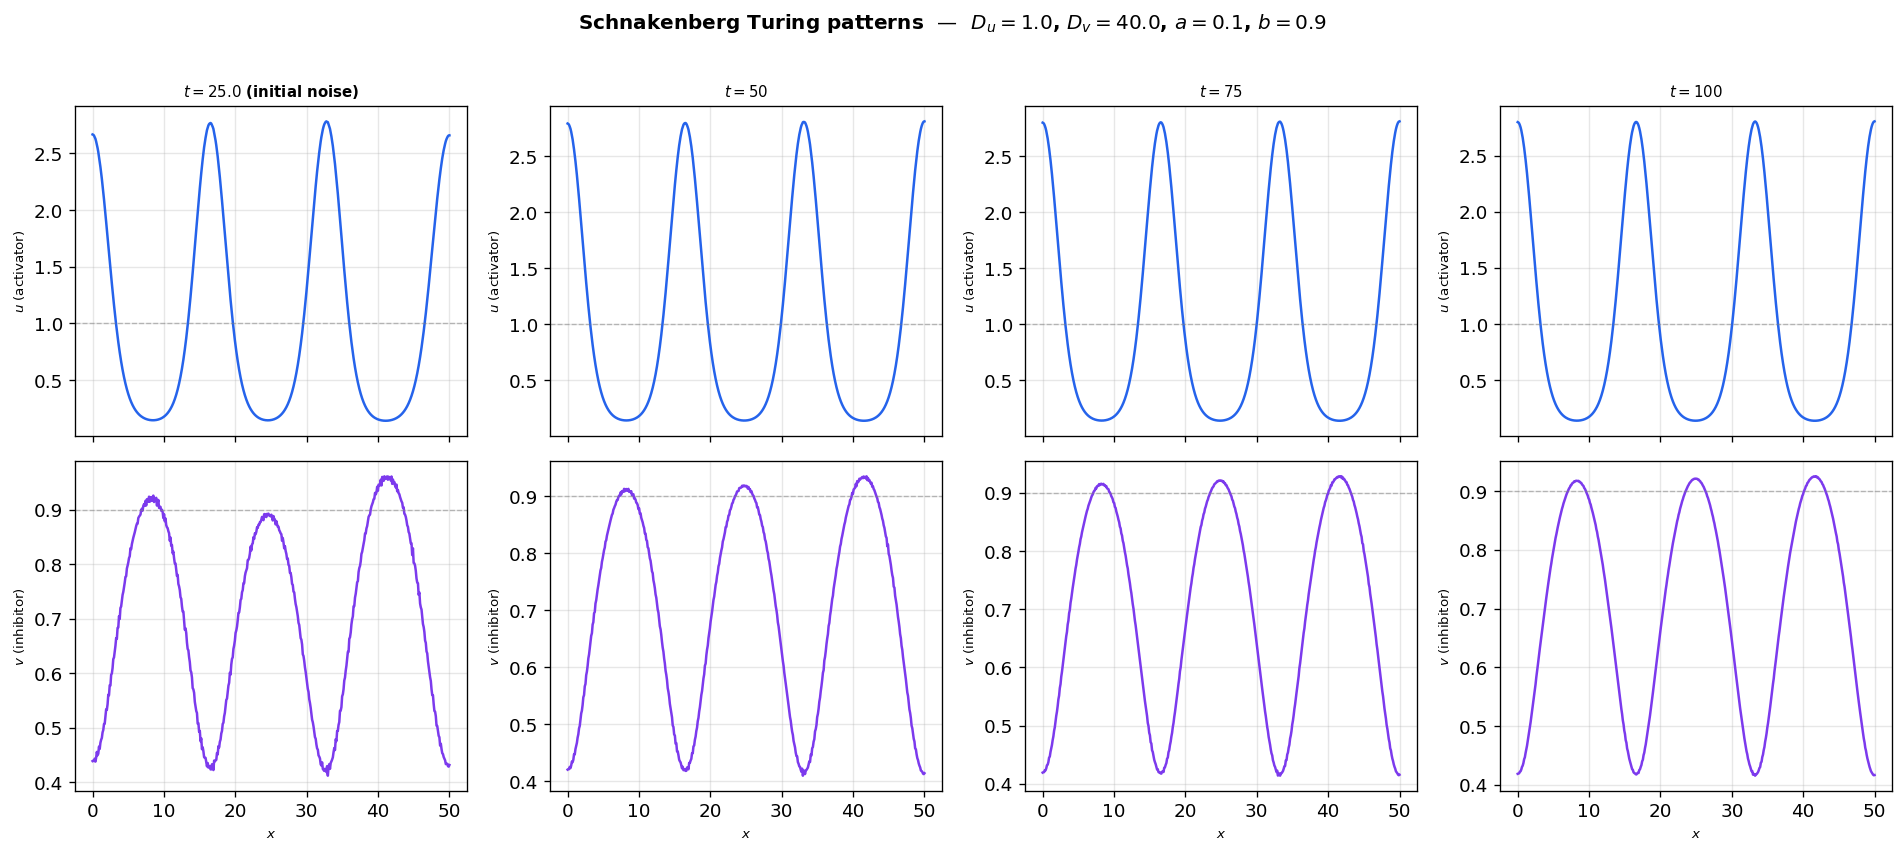

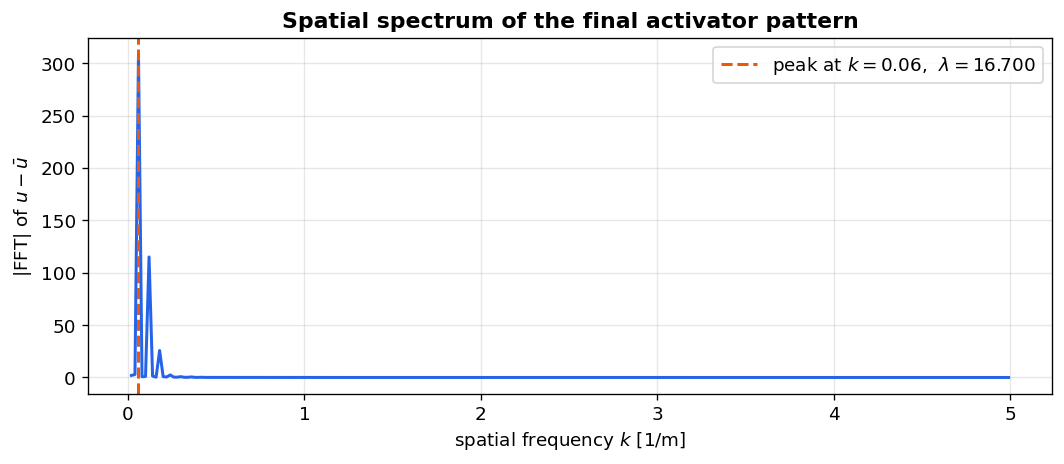

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
# 4 time snapshots: row 0 = activator u, row 1 = inhibitor v
snaps_sc = list(zip(times_sc[1:], u_snaps[1:], v_snaps[1:]))[:4]

for col, (t, u_s, v_s) in enumerate(snaps_sc):
    ax_u = axes[0, col]
    ax_v = axes[1, col]

    ax_u.plot(x_sc, u_s, color=COLORS[3], lw=1.5)
    ax_v.plot(x_sc, v_s, color=COLORS[2], lw=1.5)

    ax_u.axhline(u0_ss, color="grey", lw=0.8, ls="--", alpha=0.5)
    ax_v.axhline(v0_ss, color="grey", lw=0.8, ls="--", alpha=0.5)

    ax_u.set_title(f"$t = {t:.0f}$", fontsize=9, fontweight="bold")
    ax_u.set_ylabel("$u$ (activator)", fontsize=8)
    ax_v.set_ylabel("$v$ (inhibitor)", fontsize=8)
    ax_v.set_xlabel("$x$", fontsize=8)

axes[0, 0].set_title(f"$t = {times_sc[1]:.1f}$ (initial noise)",
                     fontsize=9, fontweight="bold")

fig.suptitle(
    rf"Schnakenberg Turing patterns  —  $D_u={Du}$, $D_v={Dv}$, "
    rf"$a={a_sc}$, $b={b_sc}$",
    fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

# Spectral analysis of the final pattern
u_final = u_snaps[-1]
u_perturb = u_final - np.mean(u_final)
fft_u = np.abs(np.fft.rfft(u_perturb))
freqs = np.fft.rfftfreq(N_sc, d=dx_sc)
peak_freq = freqs[np.argmax(fft_u[1:]) + 1]

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(freqs[1:], fft_u[1:], color=COLORS[3], lw=1.8)
ax2.axvline(peak_freq, color=COLORS[4], ls="--", lw=1.8,
            label=f"peak at $k = {peak_freq:.2f}$,  "
                  f"$\\lambda = {1/peak_freq:.3f}$")
ax2.set_xlabel("spatial frequency $k$ [1/m]")
ax2.set_ylabel("|FFT| of $u - \\bar{u}$")
ax2.set_title("Spatial spectrum of the final activator pattern", fontweight="bold")
ax2.legend()
fig2.tight_layout()
plt.show()


## 9 — Notes for Students

### Key take-aways

1. **Crank–Nicolson = average of explicit and implicit.**
   Writing the spatial derivative as the average of its values at time levels
   $k$ and $k+1$ is what gives CN its second-order time accuracy and its
   unconditional stability.  No other standard single-step finite-difference
   method achieves both simultaneously.

2. **The linear system is tridiagonal — and cheap to solve.**
   The banded structure means the LU factorisation costs $O(N)$ operations,
   exactly the same as the explicit stencil.  The only overhead is memory
   for the matrix and a small constant factor in the solve.

3. **Neumann boundary conditions fold into the corner entries.**
   Eliminating the ghost node at each Neumann boundary doubles the
   off-diagonal entry in the first and last rows of both $\mathbf{A}$
   and $\mathbf{B}$.  Everything else in the matrices is standard.

4. **Semi-implicit treatment of reactions is the practical default.**
   Treating $f(u)$ explicitly (as done here) keeps the matrix fixed across
   all time steps — it only needs to be factored once.  Treating $f$
   implicitly would require refactoring at every step (or a Newton iteration).
   The semi-implicit approach is stable as long as the *reaction* time
   scale is resolved by $\Delta t$.

5. **Two-variable systems decouple at the matrix level.**
   Each species gets its own independent tridiagonal system; the coupling
   enters only through the right-hand-side reaction vectors.  This means
   extending from one variable to $M$ variables simply adds $M$ matrix
   builds and $M$ tridiagonal solves per step.

6. **Turing patterns arise from diffusion-driven instability.**
   A homogeneous state that is *stable* to spatially uniform perturbations
   can be destabilised by spatial heterogeneity when the inhibitor diffuses
   faster than the activator ($D_v \gg D_u$).  The selected wavelength is
   set by the balance between reaction and diffusion rates, not by the
   domain size or initial condition — a striking example of self-organisation.
